# RNN Training - Anaerobic Digestion of Olive Mill Waste
### Crete Case Study

---

## Why RNN after ANN?

the ANN treats each timestep independently meaning it looks at the current state
and predicts the next rates, BUT has no memory of what happened before.

an RNN (Recurrent Neural Network) is different. it maintains a hidden state
that carries information from previous timesteps. this means when predicting
what happens on day 15, it has some memory of what happened on days 1-14.

for a bioprocess this makes biological sense in the sesnse that the history of the digester
(how fast it's been consuming substrate, how pH has been evolving) should
influence where it's heading next.

**architecture:**
input sequence → RNN layer (with tanh activation) → linear readout layer

**key difference from ANN:**
- data must be reshaped into sequences (time windows)
- the RNN processes each sequence step by step, updating hidden state
- we use a sequence window of 12 timesteps (same as original dissertation)

**inputs:** same 5 variables (S, M, pH, T, OLR)
**outputs:** same 3 rates (dS/dt, dM/dt, dpH/dt)

the ANN got mean offline MAPE of 0.45% (S), 0.29% (M), 0.02% (pH).
the question is whether the RNN can do better by using temporal context.


## 1. Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch version: 2.11.0
cuda available: False


## 2. Load Data

In [2]:
book = openpyxl.load_workbook('olive_mill_database.xlsx',
                               read_only=True, data_only=True)

sheet_ref = book['STANDARDISATION_REF']
data_ref  = []
for r in sheet_ref.iter_rows(min_row=4, values_only=True):
    data_ref.append([r[c] for c in range(8)])

sheet_train = book['PREPARED_TRAINING']
data_train  = []
for r in sheet_train.iter_rows(min_row=4, values_only=True):
    data_train.append([r[c] for c in range(8)])

print(f"reference data : {len(data_ref)} rows")
print(f"training data  : {len(data_train)} rows")

reference data : 1080 rows
training data  : 27000 rows


## 3. Standardise

In [3]:
scaler = StandardScaler()
scaler.fit(data_ref)

standardised = scaler.transform(data_train)

print("scaler fitted on reference data")
print("means: ", [round(m, 3) for m in scaler.mean_])
print("stds:  ", [round(s, 3) for s in scaler.scale_])

scaler fitted on reference data
means:  [np.float64(17.244), np.float64(6747.284), np.float64(7.109), np.float64(36.25), np.float64(3.333), np.float64(-0.928), np.float64(352.734), np.float64(-0.013)]
stds:   [np.float64(12.582), np.float64(4702.294), np.float64(0.156), np.float64(4.38), np.float64(2.055), np.float64(0.754), np.float64(286.686), np.float64(0.016)]


## 4. Create Sequences

this is the key difference from the ANN notebook.

instead of feeding individual rows to the network, we feed sequences of
consecutive timesteps. the RNN sees the last seq_len timesteps and
predicts the rates at the next step.

the training data has 27,000 rows but they come from 36 runs x 25 noise
replications x 30 timesteps. within each run the rows are time-ordered.
after shuffling they're mixed up, so we can't make sequences across the
whole dataset naively.

instead we make sequences within each run before augmentation, using the
clean 1,080-row reference data. this gives us proper time-ordered sequences.

seq_len = 12 means the RNN sees 12 days of history before predicting.
this matches the original dissertation approach.


In [4]:
seq_len = 12   # timesteps of history the RNN sees before predicting

# use standardised reference data (1080 rows, time-ordered within each run)
# each run is 30 rows. runs are in order: run1(rows 0-29), run2(rows 30-59)...
n_runs    = 36
rows_per_run = 30

# check this matches our data
assert len(data_ref) == n_runs * rows_per_run,     f"expected {n_runs * rows_per_run} rows, got {len(data_ref)}"

std_ref = scaler.transform(data_ref)
x_ref   = std_ref[:, 0:5]   # inputs
y_ref   = std_ref[:, 5:8]   # targets

# create sequences: for each run, slide a window of seq_len
sequences_x = []
sequences_y = []

for run_i in range(n_runs):
    start = run_i * rows_per_run
    end   = start + rows_per_run

    run_x = x_ref[start:end]   # (30, 5)
    run_y = y_ref[start:end]   # (30, 3)

    # slide window: seq of length seq_len predicts the rate at last step
    for t in range(rows_per_run - seq_len):
        seq_x = run_x[t : t + seq_len]         # (seq_len, 5) — input sequence
        seq_y = run_y[t + seq_len - 1]          # (5,) — target at last step
        sequences_x.append(seq_x)
        sequences_y.append(seq_y)

sequences_x = np.array(sequences_x)   # (N_seq, seq_len, 5)
sequences_y = np.array(sequences_y)   # (N_seq, 3)

print(f"sequences created:")
print(f"  seq_len       : {seq_len}")
print(f"  sequences_x   : {sequences_x.shape}  (n_sequences, seq_len, n_inputs)")
print(f"  sequences_y   : {sequences_y.shape}  (n_sequences, n_outputs)")
print(f"  sequences/run : {rows_per_run - seq_len}")
print(f"  total sequences: {len(sequences_x)}")

sequences created:
  seq_len       : 12
  sequences_x   : (648, 12, 5)  (n_sequences, seq_len, n_inputs)
  sequences_y   : (648, 3)  (n_sequences, n_outputs)
  sequences/run : 18
  total sequences: 648


In [5]:
# augment sequences with noise (same approach as original)
# replicate each sequence 25 times with Gaussian noise
NOISE_LEVEL  = 0.05 * 0.333
REPLICATIONS = 25

aug_x = []
aug_y = []

for i in range(len(sequences_x)):
    base_x = sequences_x[i]   # (seq_len, 5)
    base_y = sequences_y[i]   # (3,)
    for _ in range(REPLICATIONS):
        noisy_x = np.random.normal(base_x, np.abs(base_x) * NOISE_LEVEL + 1e-6)
        noisy_y = np.random.normal(base_y, np.abs(base_y) * NOISE_LEVEL + 1e-6)
        aug_x.append(noisy_x)
        aug_y.append(noisy_y)

aug_x = np.array(aug_x)
aug_y = np.array(aug_y)

# shuffle
idx = np.random.permutation(len(aug_x))
aug_x = aug_x[idx]
aug_y = aug_y[idx]

print(f"augmented sequences: {aug_x.shape}")
print(f"augmented targets  : {aug_y.shape}")

x_train = torch.tensor(aug_x, dtype=torch.float32)   # (N, seq_len, 5)
y_train = torch.tensor(aug_y, dtype=torch.float32)   # (N, 3)

print(f"x_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")

augmented sequences: (16200, 12, 5)
augmented targets  : (16200, 3)
x_train: torch.Size([16200, 12, 5])
y_train: torch.Size([16200, 3])


## 5. Define the RNN Model

single-layer RNN with tanh activation (standard for bioprocess modelling)
takes a sequence of inputs, processes step by step, readout from final hidden state


In [6]:
class RNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(RNNModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim  = layer_dim

        # RNN layer — batch_first=True means input shape is (batch, seq, features)
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim,
                          batch_first=True, nonlinearity='tanh')

        # linear readout — maps hidden state to output
        self.fc  = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # initialise hidden state with zeros
        h0  = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim)

        # pass sequence through RNN
        out, hn = self.rnn(x, h0.detach())

        # take output at the LAST timestep for prediction
        out = self.fc(out[:, -1, :])
        return out

# hyperparameters — starting values, will tune with K-Fold
input_dim  = 5
hidden_dim = 20
layer_dim  = 1
output_dim = 3
N          = 50
train_epochs  = 200
learning_rate = 1e-3

model   = RNNModel(input_dim, hidden_dim, layer_dim, output_dim)
loss_fn = nn.MSELoss(reduction='mean')

print("RNN model:")
print(model)
print()
total_params = sum(p.numel() for p in model.parameters())
print(f"total parameters: {total_params}")
print()

# quick forward pass check
test_out = model(x_train[:N])
print(f"forward pass OK — output shape: {test_out.shape}")

RNN model:
RNNModel(
  (rnn): RNN(5, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=3, bias=True)
)

total parameters: 603

forward pass OK — output shape: torch.Size([50, 3])


## 6. DataLoader

In [7]:
dataset    = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=N, shuffle=True)

print(f"dataset size  : {len(dataset)}")
print(f"batch size    : {N}")
print(f"batches/epoch : {len(dataloader)}")

dataset size  : 16200
batch size    : 50
batches/epoch : 324


## 7. Train

same training loop as ANN with 200 epochs as a first run, then
K-Fold will tune hidden_dim and other parameters properly


In [8]:
optimizer    = torch.optim.Adam(model.parameters(), lr=learning_rate)
loss_history = []

model.train()
print(f"training: {train_epochs} epochs, lr={learning_rate}, batch={N}")
print("-" * 55)

for epoch in range(train_epochs):
    epoch_loss = 0.0
    for x_batch, y_batch in dataloader:
        y_pred = model(x_batch)
        loss   = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() / len(dataloader)
    loss_history.append(epoch_loss)
    if epoch % 20 == 0 or epoch == train_epochs - 1:
        print(f"epoch {epoch:>4d}   loss = {epoch_loss:.6f}")

print("-" * 55)
print(f"done. final loss: {loss_history[-1]:.6f}")
print(f"ANN final loss was: 0.001549")

training: 200 epochs, lr=0.001, batch=50
-------------------------------------------------------
epoch    0   loss = 0.039050
epoch   20   loss = 0.000182
epoch   40   loss = 0.000168
epoch   60   loss = 0.000160
epoch   80   loss = 0.000164
epoch  100   loss = 0.000149
epoch  120   loss = 0.000146
epoch  140   loss = 0.000145
epoch  160   loss = 0.000138
epoch  180   loss = 0.000144
epoch  199   loss = 0.000138
-------------------------------------------------------
done. final loss: 0.000138
ANN final loss was: 0.001549


## 8. Loss Curve

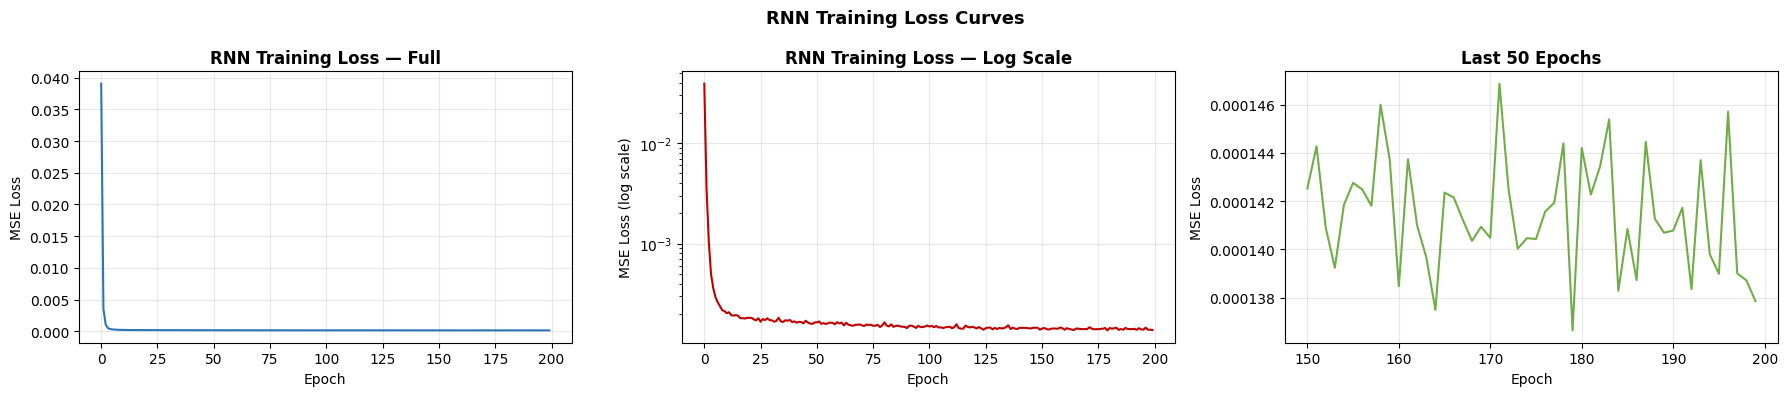

starting loss   : 0.039050
final loss      : 0.000138
reduction       : 99.6%
last 50 drop    : 0.0000047
CONVERGED


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(loss_history, color='#2E75B6', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('RNN Training Loss — Full', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(loss_history, color='#C00000', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('RNN Training Loss — Log Scale', fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(range(train_epochs-50, train_epochs),
             loss_history[-50:], color='#70AD47', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MSE Loss')
axes[2].set_title('Last 50 Epochs', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('RNN Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

last50_drop = loss_history[-50] - loss_history[-1]
print(f"starting loss   : {loss_history[0]:.6f}")
print(f"final loss      : {loss_history[-1]:.6f}")
print(f"reduction       : {((loss_history[0]-loss_history[-1])/loss_history[0])*100:.1f}%")
print(f"last 50 drop    : {last50_drop:.7f}")
if last50_drop < 0.00005:
    print("CONVERGED")
elif last50_drop < 0.0002:
    print("nearly converged")
else:
    print("still decreasing — K-Fold will use more epochs or tune lr")

## 9. Predicted vs Actual

note: these are predictions on the SEQUENCE training data,
not the original per-timestep format. the input is a window of
12 consecutive steps and the output is the rate at step 12.


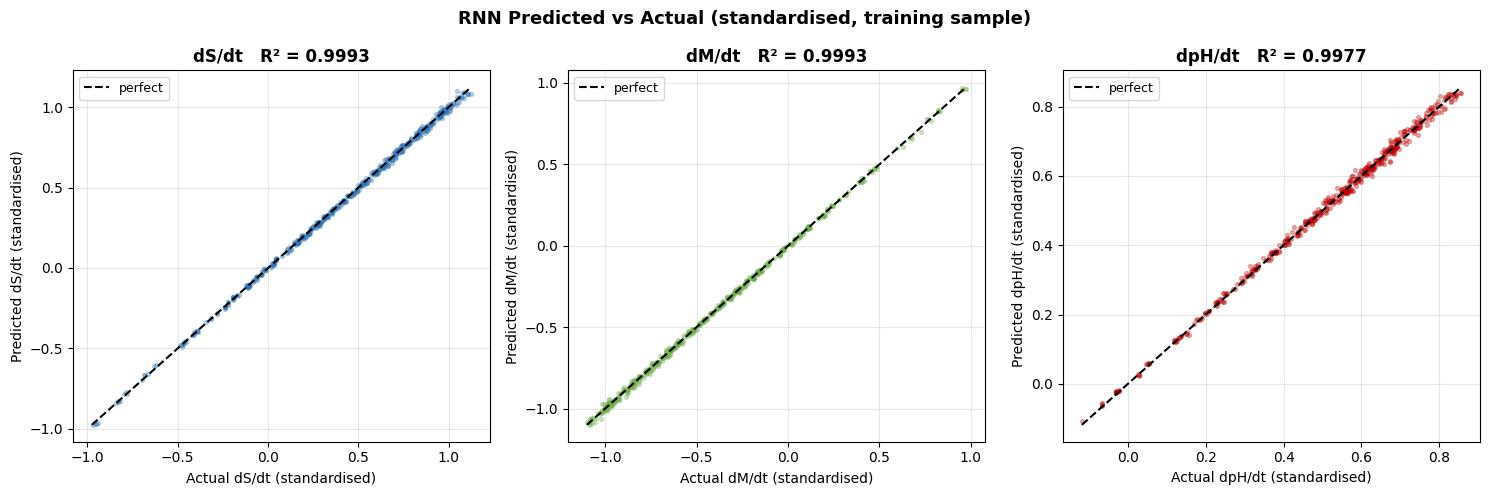

R² values:
  dS/dt     : 0.9993  (ANN was 0.9982, delta +0.0011)
  dM/dt     : 0.9993  (ANN was 0.9984, delta +0.0009)
  dpH/dt    : 0.9977  (ANN was 0.9989, delta -0.0012)


In [10]:
model.eval()
with torch.no_grad():
    sample_x = x_train[:500]
    sample_y = y_train[:500]
    preds    = model(sample_x)

preds_np  = preds.numpy()
actual_np = sample_y.numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
target_names = ['dS/dt', 'dM/dt', 'dpH/dt']
colors = ['#2E75B6', '#70AD47', '#C00000']

r2_vals = []
for i, (ax, name, col) in enumerate(zip(axes, target_names, colors)):
    ax.scatter(actual_np[:, i], preds_np[:, i],
               alpha=0.3, s=8, color=col)
    lims = [min(actual_np[:,i].min(), preds_np[:,i].min()),
            max(actual_np[:,i].max(), preds_np[:,i].max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='perfect')
    ss_res = np.sum((actual_np[:,i] - preds_np[:,i])**2)
    ss_tot = np.sum((actual_np[:,i] - actual_np[:,i].mean())**2)
    r2 = 1 - ss_res/ss_tot
    r2_vals.append(r2)
    ax.set_xlabel(f'Actual {name} (standardised)')
    ax.set_ylabel(f'Predicted {name} (standardised)')
    ax.set_title(f'{name}   R² = {r2:.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('RNN Predicted vs Actual (standardised, training sample)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("R² values:")
ann_r2 = [0.9982, 0.9984, 0.9989]
for name, r2, ar2 in zip(target_names, r2_vals, ann_r2):
    delta = r2 - ar2
    delta_str = f'+{delta:.4f}' if delta >= 0 else f'{delta:.4f}'
    print(f"  {name:<10}: {r2:.4f}  (ANN was {ar2:.4f}, delta {delta_str})")

## 10. Residual Analysis

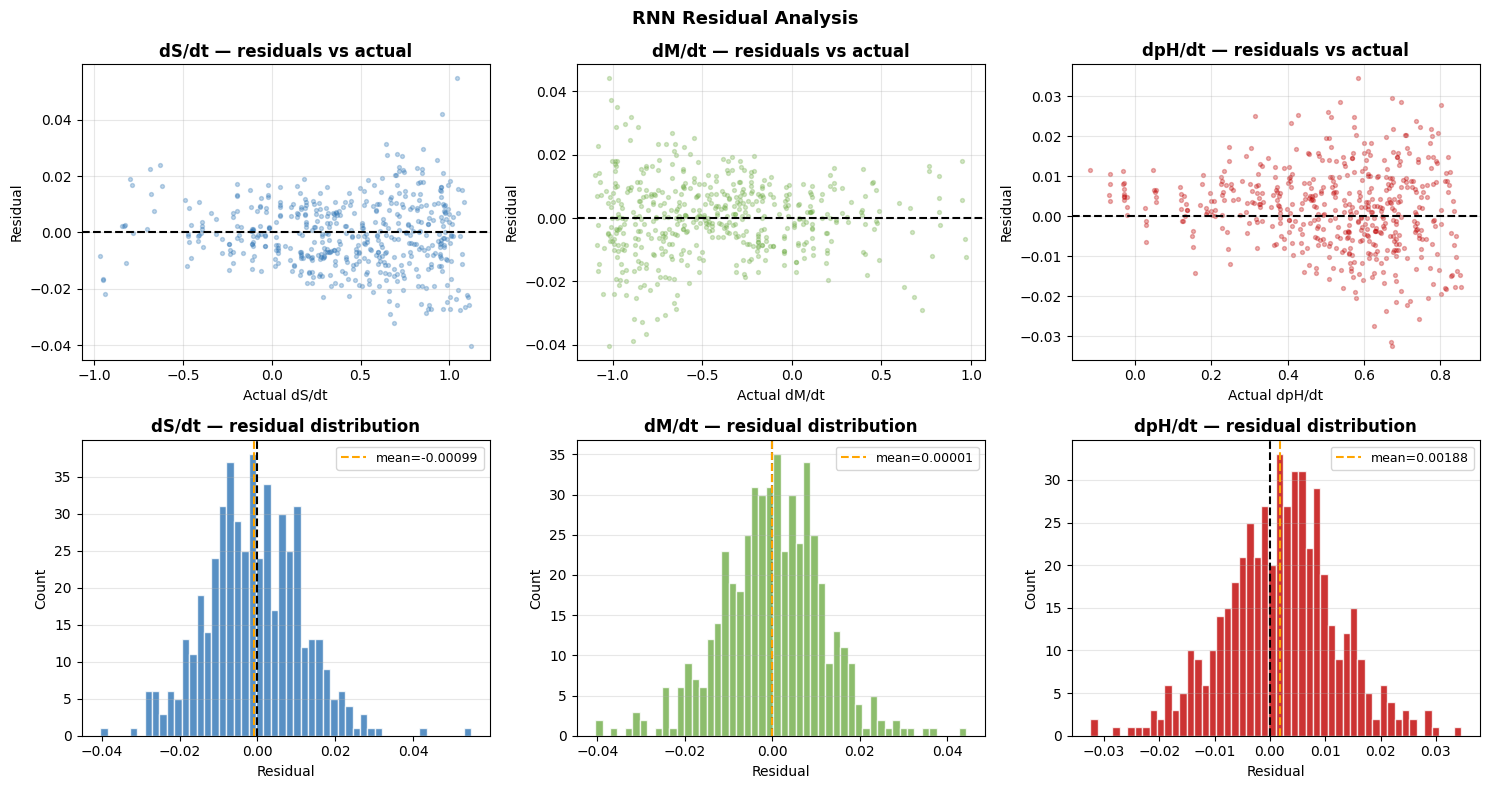

residual means (should be ~0):
  dS/dt: -0.000992
  dM/dt: 0.000012
  dpH/dt: 0.001881


In [11]:
residuals = preds_np - actual_np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, (name, col) in enumerate(zip(target_names, colors)):
    axes[0, i].scatter(actual_np[:, i], residuals[:, i],
                       alpha=0.3, s=8, color=col)
    axes[0, i].axhline(0, color='black', linewidth=1.5, linestyle='--')
    axes[0, i].set_xlabel(f'Actual {name}')
    axes[0, i].set_ylabel('Residual')
    axes[0, i].set_title(f'{name} — residuals vs actual', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].hist(residuals[:, i], bins=50, color=col,
                    alpha=0.8, edgecolor='white')
    axes[1, i].axvline(0, color='black', linewidth=1.5, linestyle='--')
    axes[1, i].axvline(residuals[:, i].mean(), color='orange',
                       linewidth=1.5, linestyle='--',
                       label=f'mean={residuals[:,i].mean():.5f}')
    axes[1, i].set_xlabel('Residual')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'{name} — residual distribution', fontweight='bold')
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('RNN Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("residual means (should be ~0):")
for i, name in enumerate(target_names):
    print(f"  {name}: {residuals[:,i].mean():.6f}")

## 11. Save Model

In [12]:
torch.save(model.state_dict(), 'RNN_olive_mill.pt')
np.save('scaler_mean.npy',  scaler.mean_)
np.save('scaler_scale.npy', scaler.scale_)

print("saved: RNN_olive_mill.pt")
print()
print("to reload:")
print(f"  model = RNNModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print("  model.load_state_dict(torch.load('RNN_olive_mill.pt'))")
print("  model.eval()")
print()
print("next step: RNN_KFold_Olive_Mill.ipynb")
print(f"  tune: hidden_dim (currently {hidden_dim})")
print(f"  tune: learning rate (currently {learning_rate})")
print(f"  tune: batch size (currently {N})")
print(f"  keep: seq_len={seq_len}, layer_dim={layer_dim}")

saved: RNN_olive_mill.pt

to reload:
  model = RNNModel(5, 20, 1, 3)
  model.load_state_dict(torch.load('RNN_olive_mill.pt'))
  model.eval()

next step: RNN_KFold_Olive_Mill.ipynb
  tune: hidden_dim (currently 20)
  tune: learning rate (currently 0.001)
  tune: batch size (currently 50)
  keep: seq_len=12, layer_dim=1


## 12. Summary

In [13]:
print("=" * 55)
print("RNN TRAINING SUMMARY (first run)")
print("=" * 55)
print(f"  architecture  : RNNModel({input_dim}, {hidden_dim}, {layer_dim}, {output_dim})")
print(f"  parameters    : {sum(p.numel() for p in model.parameters())}")
print(f"  sequence len  : {seq_len}")
print(f"  training seqs : {len(x_train)}")
print(f"  epochs        : {train_epochs}")
print(f"  learning rate : {learning_rate}")
print(f"  batch size    : {N}")
print(f"  final MSE loss: {loss_history[-1]:.6f}")
print(f"  ANN final loss: 0.001549")
print("=" * 55)

RNN TRAINING SUMMARY (first run)
  architecture  : RNNModel(5, 20, 1, 3)
  parameters    : 603
  sequence len  : 12
  training seqs : 16200
  epochs        : 200
  learning rate : 0.001
  batch size    : 50
  final MSE loss: 0.000138
  ANN final loss: 0.001549
